# Fluid models: Test of code vs. published figures

All code is based on Michael Batzle and Zhijing Wang: Seismic properties of pore fluids. Geophysics, vol 57, no. 11 (november 1992); pp 1396-1408.

## Gas models

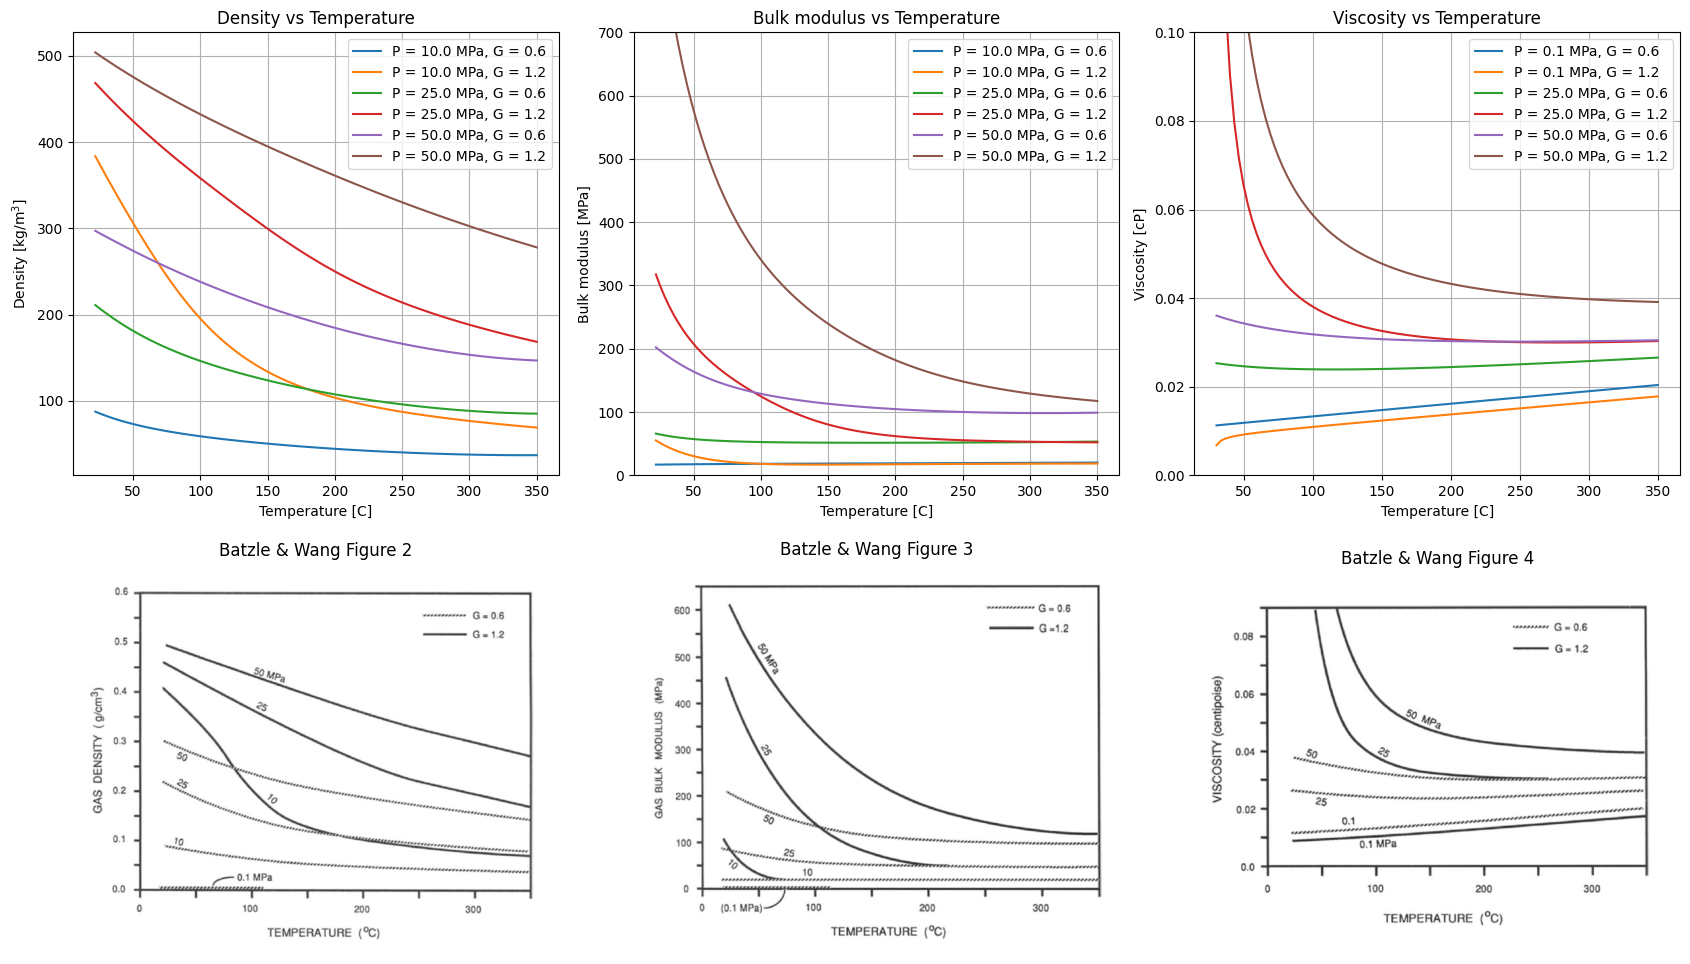

In [19]:
import matplotlib.pyplot as plt
import numpy as np

from rock_physics_open.fluid_models.gas_model.gas_properties import (
    gas_bulk_modulus,
    gas_density,
    gas_viscosity,
)

temp_c = np.linspace(22, 350, 100).astype(float)
temp_c_visc = np.linspace(30, 350, 100).astype(float)
abs_temperature = 273.15 + temp_c
abs_temperature_visc = 273.15 + temp_c_visc

gas_gravity_1 = 0.6 * np.ones_like(abs_temperature)
gas_gravity_2 = 1.2 * np.ones_like(abs_temperature)

pressure_0 = 0.1e6 * np.ones_like(abs_temperature)
pressure_1 = 10.0e6 * np.ones_like(abs_temperature)
pressure_2 = 25.0e6 * np.ones_like(abs_temperature)
pressure_3 = 50.0e6 * np.ones_like(abs_temperature)

gas_dens = [
    gas_density(abs_temperature, pres, grav)
    for pres in [pressure_1, pressure_2, pressure_3]
    for grav in [gas_gravity_1, gas_gravity_2]
]
gas_k = [
    1.0e-6 * gas_bulk_modulus(abs_temperature, pres, grav)
    for pres in [pressure_1, pressure_2, pressure_3]
    for grav in [gas_gravity_1, gas_gravity_2]
]
gas_eta = [
    gas_viscosity(abs_temperature_visc, pres, grav)
    for pres in [pressure_0, pressure_2, pressure_3]
    for grav in [gas_gravity_1, gas_gravity_2]
]
label_dens = [
    f"P = {pres / 1.0e6} MPa, G = {grav}"
    for pres in [pressure_1[0], pressure_2[0], pressure_3[0]]
    for grav in [gas_gravity_1[0], gas_gravity_2[0]]
]
labels_eta = [
    f"P = {pres / 1.0e6} MPa, G = {grav}"
    for pres in [pressure_0[0], pressure_2[0], pressure_3[0]]
    for grav in [gas_gravity_1[0], gas_gravity_2[0]]
]

fig, ax = plt.subplots(2, 3, figsize=(17, 10))

for dens, bulk, eta, lab, lab_eta in zip(
    gas_dens, gas_k, gas_eta, label_dens, labels_eta
):
    ax[0, 0].plot(temp_c, dens, label=lab)
    ax[0, 1].plot(temp_c, bulk, label=lab)
    ax[0, 2].plot(temp_c_visc, eta, label=lab_eta)

ax[0, 0].title.set_text("Density vs Temperature")
ax[0, 0].set_ylabel("Density [kg/m$^3$]")
ax[0, 0].set_xlabel("Temperature [C]")
ax[0, 0].grid()
ax[0, 0].legend()

ax[0, 1].title.set_text("Bulk modulus vs Temperature")
ax[0, 1].set_ylabel("Bulk modulus [MPa]")
ax[0, 1].set_xlabel("Temperature [C]")
ax[0, 1].set_ylim([0.0, 700])
ax[0, 1].grid()
ax[0, 1].legend()

ax[0, 2].title.set_text("Viscosity vs Temperature")
ax[0, 2].set_ylabel("Viscosity [cP]")
ax[0, 2].set_xlabel("Temperature [C]")
ax[0, 2].set_ylim([0.0, 0.1])
ax[0, 2].grid()
ax[0, 2].legend()

# Second row: images
image_files = [
    "images/bw_1992_fig_2_gas_density.png",
    "images/bw_1992_fig_3_gas_bulk_modulus.png",
    "images/bw_1992_fig_4_gas_viscosity.png",
]
titles = ["Batzle & Wang Figure 2", "Batzle & Wang Figure 3", "Batzle & Wang Figure 4"]

for i, (img_file, title) in enumerate(zip(image_files, titles)):
    img = plt.imread(img_file)
    ax[1, i].imshow(img)
    ax[1, i].axis("off")
    ax[1, i].set_title(title)

plt.tight_layout()

plt.show()

## Oil models

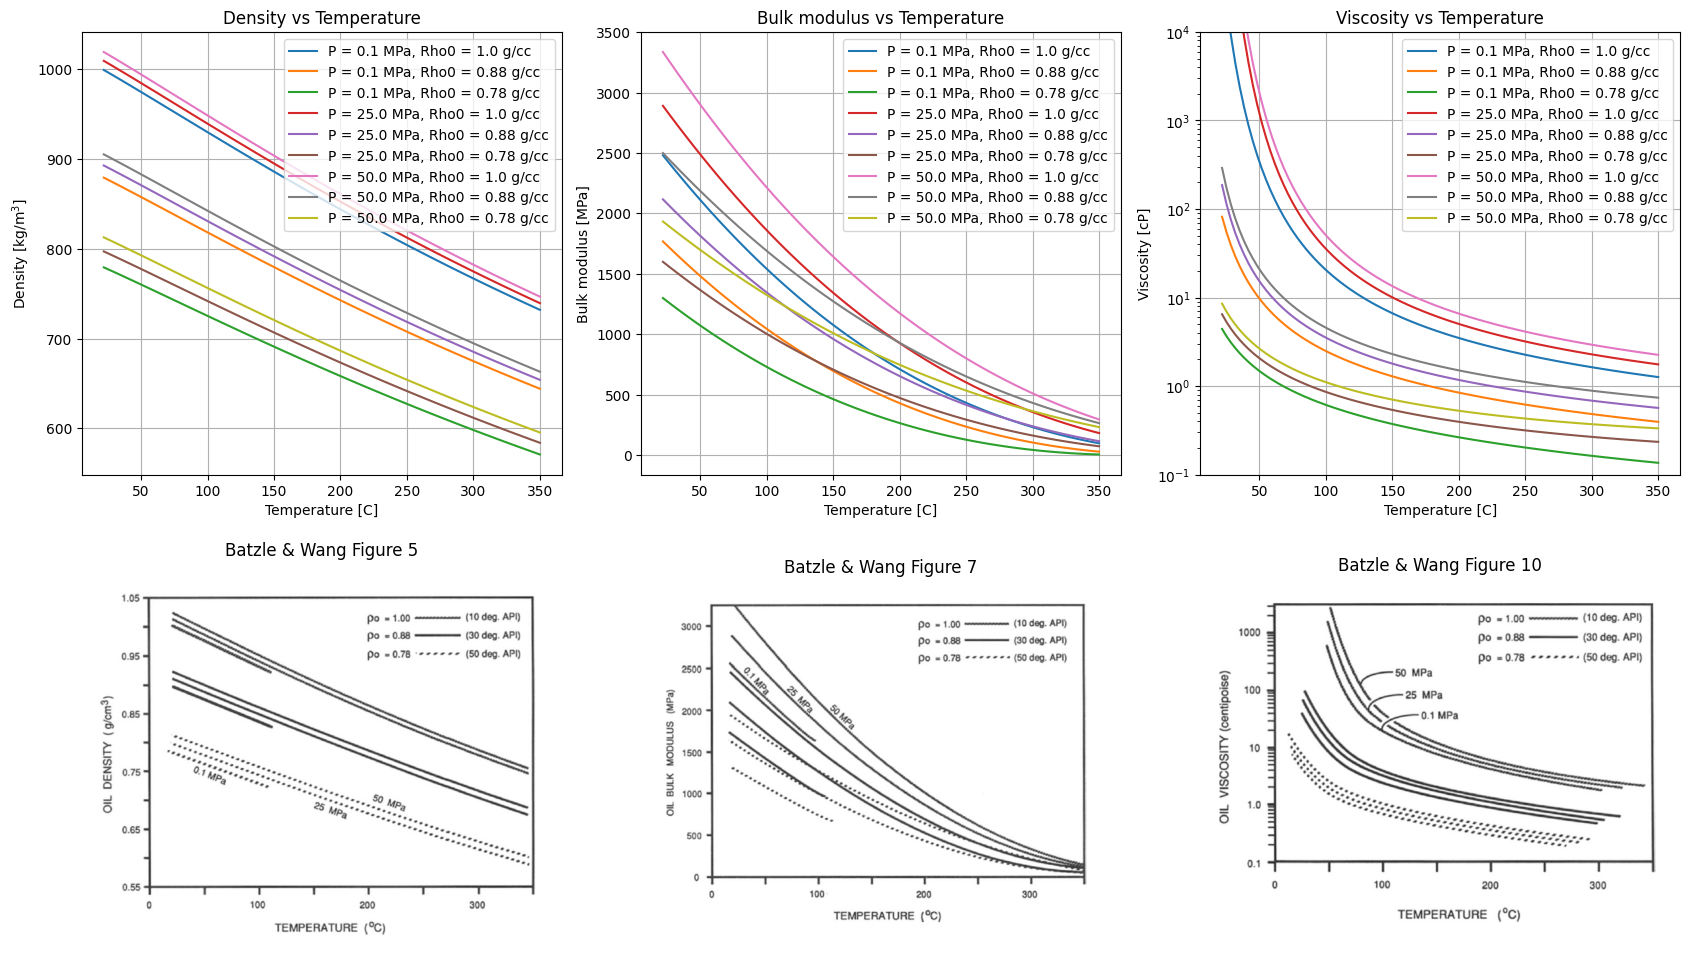

In [20]:
import matplotlib.pyplot as plt
import numpy as np

from rock_physics_open.fluid_models.oil_model.dead_oil_density import dead_oil_density
from rock_physics_open.fluid_models.oil_model.dead_oil_velocity import dead_oil_velocity
from rock_physics_open.fluid_models.oil_model.oil_properties import oil_viscosity

temp_c = np.linspace(22, 350, 100).astype(float)
abs_temperature = 273.15 + temp_c

pressure_1 = 10.0e6 * np.ones_like(abs_temperature)
pressure_2 = 25.0e6 * np.ones_like(abs_temperature)
pressure_3 = 50.0e6 * np.ones_like(abs_temperature)
pressure_0 = 0.1e6 * np.ones_like(abs_temperature)

oil_rho0_0 = 1000.0 * np.ones_like(abs_temperature)
oil_rho0_1 = 880.0 * np.ones_like(abs_temperature)
oil_rho0_2 = 780.0 * np.ones_like(abs_temperature)

oil_dens = [
    dead_oil_density(temp_c, pres, rho)
    for pres in [pressure_0, pressure_2, pressure_3]
    for rho in [oil_rho0_0, oil_rho0_1, oil_rho0_2]
]
oil_vp = [
    dead_oil_velocity(temp_c, pres, rho)
    for pres in [pressure_0, pressure_2, pressure_3]
    for rho in [oil_rho0_0, oil_rho0_1, oil_rho0_2]
]
oil_eta = [
    oil_viscosity(temp_c, pres, rho)
    for pres in [pressure_0, pressure_2, pressure_3]
    for rho in [oil_rho0_0, oil_rho0_1, oil_rho0_2]
]
oil_k = [1.0e-6 * rho * vp**2 for rho, vp in zip(oil_dens, oil_vp)]  # Plot in MPa
label = [
    f"P = {pres / 1.0e6} MPa, Rho0 = {rho / 1.0e3} g/cc"
    for pres in [pressure_0[0], pressure_2[0], pressure_3[0]]
    for rho in [oil_rho0_0[0], oil_rho0_1[0], oil_rho0_2[0]]
]

fig, ax = plt.subplots(2, 3, figsize=(17, 10))

for (
    dens,
    bulk,
    eta,
    lab,
) in zip(oil_dens, oil_k, oil_eta, label):
    ax[0, 0].plot(temp_c, dens, label=lab)
    ax[0, 1].plot(temp_c, bulk, label=lab)
    ax[0, 2].plot(temp_c, eta, label=lab)

ax[0, 0].title.set_text("Density vs Temperature")
ax[0, 0].set_ylabel("Density [kg/m$^3$]")
ax[0, 0].set_xlabel("Temperature [C]")
ax[0, 0].grid()
ax[0, 0].legend()

ax[0, 1].title.set_text("Bulk modulus vs Temperature")
ax[0, 1].set_ylabel("Bulk modulus [MPa]")
ax[0, 1].set_xlabel("Temperature [C]")
ax[0, 1].grid()
ax[0, 1].legend()

ax[0, 2].title.set_text("Viscosity vs Temperature")
ax[0, 2].set_ylabel("Viscosity [cP]")
ax[0, 2].set_xlabel("Temperature [C]")
ax[0, 2].set_yscale("log")
ax[0, 2].set_ylim([0.1, 10000.0])
ax[0, 2].grid()
ax[0, 2].legend()


# Second row: images
image_files = [
    "images/bw_1992_fig_5_oil_density.png",
    "images/bw_1992_fig_7_oil_bulk_modulus.png",
    "images/bw_1992_fig_10_oil_viscosity.png",
]
titles = ["Batzle & Wang Figure 5", "Batzle & Wang Figure 7", "Batzle & Wang Figure 10"]

for i, (img_file, title) in enumerate(zip(image_files, titles)):
    img = plt.imread(img_file)
    ax[1, i].imshow(img)
    ax[1, i].axis("off")
    ax[1, i].set_title(title)

plt.tight_layout()

plt.show()

## Brine models

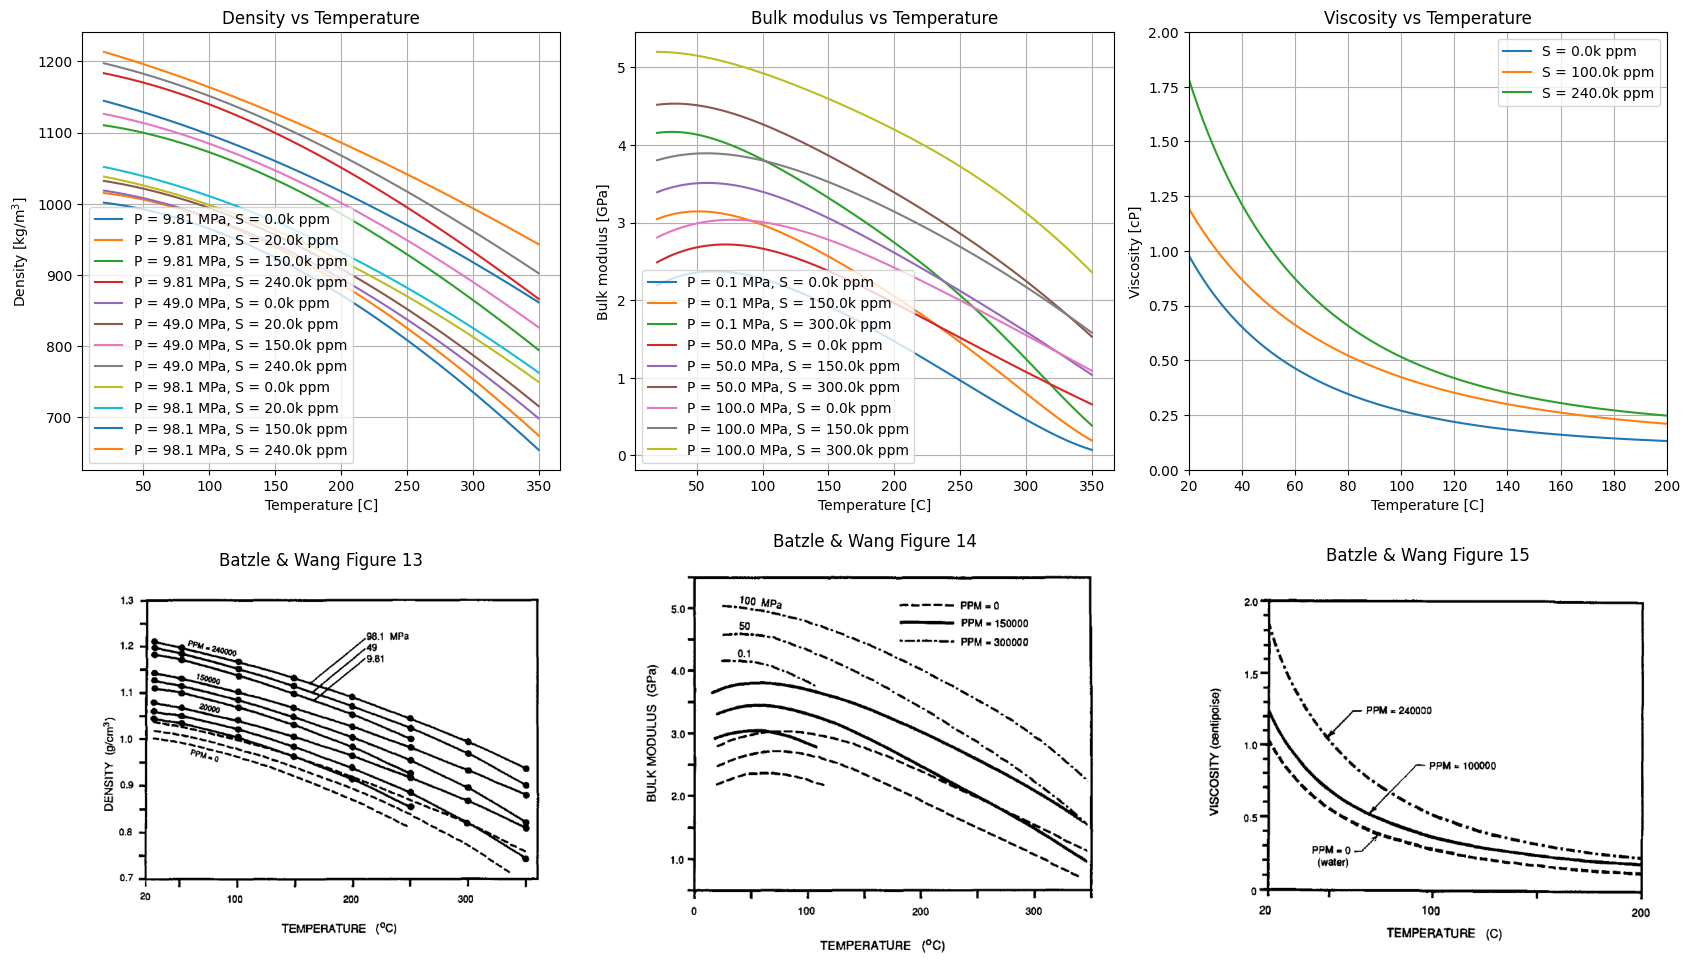

In [21]:
import matplotlib.pyplot as plt
import numpy as np

from rock_physics_open.fluid_models.brine_model.brine_properties import (
    brine_density,
    brine_properties,
    brine_viscosity,
)

temp_c = np.linspace(20, 350, 100).astype(float)
temp_c_visc = np.linspace(20, 200, 100).astype(float)

# Density figure settings
pressure_d1 = 9.81e6 * np.ones_like(temp_c)
pressure_d2 = 49.0e6 * np.ones_like(temp_c)
pressure_d3 = 98.1e6 * np.ones_like(temp_c)

brine_sal_d0 = 0.0 * np.ones_like(temp_c)
brine_sal_d1 = 20.0e3 * np.ones_like(temp_c)
brine_sal_d2 = 150.0e3 * np.ones_like(temp_c)
brine_sal_d3 = 240.0e3 * np.ones_like(temp_c)

# Bulk modulus figure settings
pressure_b1 = 0.1e6 * np.ones_like(temp_c)
pressure_b2 = 50.0e6 * np.ones_like(temp_c)
pressure_b3 = 100.0e6 * np.ones_like(temp_c)

brine_sal_b0 = 0.0 * np.ones_like(temp_c)
brine_sal_b1 = 1.5e5 * np.ones_like(temp_c)
brine_sal_b2 = 3.0e5 * np.ones_like(temp_c)

# Viscosity figure settings
brine_sal_0 = 0.0 * np.ones_like(temp_c)
brine_sal_1 = 1.0e5 * np.ones_like(temp_c)
brine_sal_2 = 2.4e5 * np.ones_like(temp_c)

brine_dens = [
    brine_density(temp_c, pres, sal)
    for pres in [pressure_d1, pressure_d2, pressure_d3]
    for sal in [brine_sal_d0, brine_sal_d1, brine_sal_d2, brine_sal_d3]
]
label_dens = [
    f"P = {pres / 1e6} MPa, S = {sal / 1e3}k ppm"
    for pres in [pressure_d1[0], pressure_d2[0], pressure_d3[0]]
    for sal in [brine_sal_d0[0], brine_sal_d1[0], brine_sal_d2[0], brine_sal_d3[0]]
]
brine_dens1 = [
    brine_properties(temp_c, pres, sal)[1]
    for pres in [pressure_d1, pressure_d2, pressure_d3]
    for sal in [brine_sal_d0, brine_sal_d1, brine_sal_d2]
]

brine_k = [
    brine_properties(temp_c, pres, sal)[2]
    for pres in [pressure_b1, pressure_b2, pressure_b3]
    for sal in [brine_sal_b0, brine_sal_b1, brine_sal_b2]
]
label_bulk = [
    f"P = {pres / 1e6} MPa, S = {sal / 1e3}k ppm"
    for pres in [pressure_b1[0], pressure_b2[0], pressure_b3[0]]
    for sal in [brine_sal_b0[0], brine_sal_b1[0], brine_sal_b2[0]]
]

brine_eta = [
    brine_viscosity(temp_c_visc, sal) for sal in [brine_sal_0, brine_sal_1, brine_sal_2]
]
label_visco = [
    f"S = {sal / 1e3}k ppm" for sal in [brine_sal_0[0], brine_sal_1[0], brine_sal_2[0]]
]


fig, ax = plt.subplots(2, 3, figsize=(17, 10))

# Plot results, first row
for (
    dens,
    lab,
) in zip(brine_dens, label_dens):
    ax[0, 0].plot(temp_c, dens, label=lab)

for k, lab in zip(brine_k, label_bulk):
    ax[0, 1].plot(temp_c, k / 1.0e9, label=lab)

for visco, lab in zip(brine_eta, label_visco):
    ax[0, 2].plot(temp_c_visc, visco, label=lab)

ax[0, 0].title.set_text("Density vs Temperature")
ax[0, 0].set_ylabel("Density [kg/m$^3$]")
ax[0, 0].set_xlabel("Temperature [C]")
ax[0, 0].grid()
ax[0, 0].legend()

ax[0, 1].title.set_text("Bulk modulus vs Temperature")
ax[0, 1].set_ylabel("Bulk modulus [GPa]")
ax[0, 1].set_xlabel("Temperature [C]")
ax[0, 1].grid()
ax[0, 1].legend()

ax[0, 2].title.set_text("Viscosity vs Temperature")
ax[0, 2].set_ylabel("Viscosity [cP]")
ax[0, 2].set_xlabel("Temperature [C]")
ax[0, 2].set_ylim([0.0, 2.0])
ax[0, 2].set_xlim([20, 200])
ax[0, 2].grid()
ax[0, 2].legend()

# Second row: images
image_files = [
    "images/bw_1992_fig_13_brine_density.png",
    "images/bw_1992_fig_14_brine_bulk_modulus.png",
    "images/bw_1992_fig_15_brine_viscosity.png",
]
titles = [
    "Batzle & Wang Figure 13",
    "Batzle & Wang Figure 14",
    "Batzle & Wang Figure 15",
]

for i, (img_file, title) in enumerate(zip(image_files, titles)):
    img = plt.imread(img_file)
    ax[1, i].imshow(img)
    ax[1, i].axis("off")
    ax[1, i].set_title(title)

plt.tight_layout()

plt.show()